In [ ]:
import sys
import os
sys.path.append(os.path.abspath("../"))

In [ ]:
from utils.loaders import load_sweep
from utils.styles import apply
from utils.analysis import cbs_profiles, linear, circular, keep, phi_cut, azimuthal_average

import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

apply(context="paper", col="single")

In [ ]:
save_path = "/Users/niaggar/Results"
fraction_list = np.linspace(0.0, 1.0, 11)

data = [
    (f"{i:04d}_fraction_{frac:.2f}", rf"f={frac:.2f}") for i, frac in enumerate(fraction_list)
]

print(data)

# Linear Polarization study of RGD particles

In [ ]:
folder = "study_mixture_layer__PLIN"
sweep_data = load_sweep(folder, base_path=Path(save_path))

data_keys = list(sweep_data.keys())
print(f"Loaded {len(data_keys)} datasets: {data_keys}")

In [ ]:
fig, (axes1, axes2) = plt.subplots(1, 2, figsize=(10, 5))

for ch, title in data:
    prof = cbs_profiles(
        sweep_data[ch].processed_cbs("farfield_cbs"),
        basis=linear, time_index=0, reduce=phi_cut(0),
    )
    th = prof.theta * 1e3
    Ico = prof.enhancement["co"]
    Icross = prof.enhancement["cross"]

    axes1.plot(th, Ico, label=title)
    axes2.plot(th, Icross, label=title)

axes1.set_xlabel(r"$\theta$ [mrad]")
axes1.set_ylabel(r"Enhancement")
axes1.set_ylim(0.9, 2.1)
axes1.grid(alpha=0.2)
axes1.legend(loc="upper right", fontsize=8)
axes2.set_xlabel(r"$\theta$ [mrad]")
axes2.set_ylabel(r"Enhancement")
axes2.set_ylim(0.9, 2.1)
axes2.grid(alpha=0.2)
axes2.legend(loc="upper right", fontsize=8)
fig.tight_layout()
# fig.savefig(out, dpi=200)
plt.show()
    

In [ ]:
for ch, title in data:
    params = sweep_data[ch].params

    print(f"\nDataset: {ch} - {title}")
    print("anisotropy_g_eff", params.extra["anisotropy_g_eff"])
    print("transport_mean_free_path", params.extra["transport_mean_free_path"])
    print("theta_coherent", params.extra["theta_coherent"])

    print( params.extra)

In [ ]:
fig, axes = plt.subplots(
    1, 5, figsize=(11, 3.6),
)

for ax, (ch, title) in zip(axes, data):
    prof_0 = cbs_profiles(
        sweep_data[ch].processed_cbs("farfield_cbs"),
        basis=linear, time_index=0, reduce=phi_cut(0),
    )
    prof_45 = cbs_profiles(
        sweep_data[ch].processed_cbs("farfield_cbs"),
        basis=linear, time_index=0, reduce=phi_cut(1),
    )
    prof_90 = cbs_profiles(
        sweep_data[ch].processed_cbs("farfield_cbs"),
        basis=linear, time_index=0, reduce=phi_cut(2),
    )

    th = prof_0.theta * 1e3
    I_0 = prof_0.enhancement["co"]
    I_45 = prof_45.enhancement["co"]
    I_90 = prof_90.enhancement["co"]
    ax.plot(th, I_0, label=r"$\phi=0^\circ$")
    ax.plot(th, I_45, label=r"$\phi=45^\circ$")
    ax.plot(th, I_90, label=r"$\phi=90^\circ$")
    ax.set_title(title, pad=12)
    ax.set_xlabel(r"$\theta$ [mrad]")
    ax.set_ylim(0.9, 2.1)
    ax.legend(loc="upper right", fontsize=8)

fig.tight_layout()
# fig.savefig(out, dpi=200)
plt.show()

In [ ]:
save_path = "/Users/niaggar/Results"
fraction_list = np.linspace(0.0, 1.0, 11)

data_mixt = [
    (f"{i:04d}_fraction_{frac:.2f}", rf"f={frac:.2f}") for i, frac in enumerate(fraction_list)
]

data_homo = [
    ("0000_radius_0.02", r"R=20 $\mu$m"),
    ("0001_radius_0.04", r"R=44 $\mu$m"),
    ("0002_radius_0.06", r"R=60 $\mu$m"),
    ("0003_radius_0.07", r"R=70 $\mu$m"),
    ("0004_radius_0.17", r"R=175 $\mu$m")
]

folder_mixt_lin = "study_mixture_layer__PLIN"
folder_homo_lin = "study_rgd_particles__PLIN"

sweep_data_mixt_lin = load_sweep(folder_mixt_lin, base_path=Path(save_path))
sweep_data_homo_lin = load_sweep(folder_homo_lin, base_path=Path(save_path))

print(f"Loaded {len(sweep_data_mixt_lin.keys())} datasets: {sweep_data_mixt_lin.keys()}")
print(f"Loaded {len(sweep_data_homo_lin.keys())} datasets: {sweep_data_homo_lin.keys()}")



In [12]:
base_00 = sweep_data_mixt_lin["0000_fraction_0.00"]
base_10 = sweep_data_mixt_lin["0010_fraction_1.00"]

base_rad_00 = sweep_data_homo_lin["0001_radius_0.04"]
base_rad_10 = sweep_data_homo_lin["0003_radius_0.07"]


print(base_00.params.extra["scattering_mean_free_path"], base_00.params.extra["mean_free_paths"])
print(base_rad_00.params.extra["mean_free_path"])

print(base_10.params.extra["scattering_mean_free_path"], base_00.params.extra["mean_free_paths"])
print(base_rad_10.params.extra["mean_free_path"])

17.35333355616835 [17.353333556168348, 111.66582435273766]
111.66582435273766
17.353333556168348 [17.353333556168348, 111.66582435273766]
17.353333556168348


## Linear Polarization ZOOM

[gate linear x=0 vs r=0.035] chi2/bin = 11791.58 (esperado ~1 si coinciden dentro del ruido)


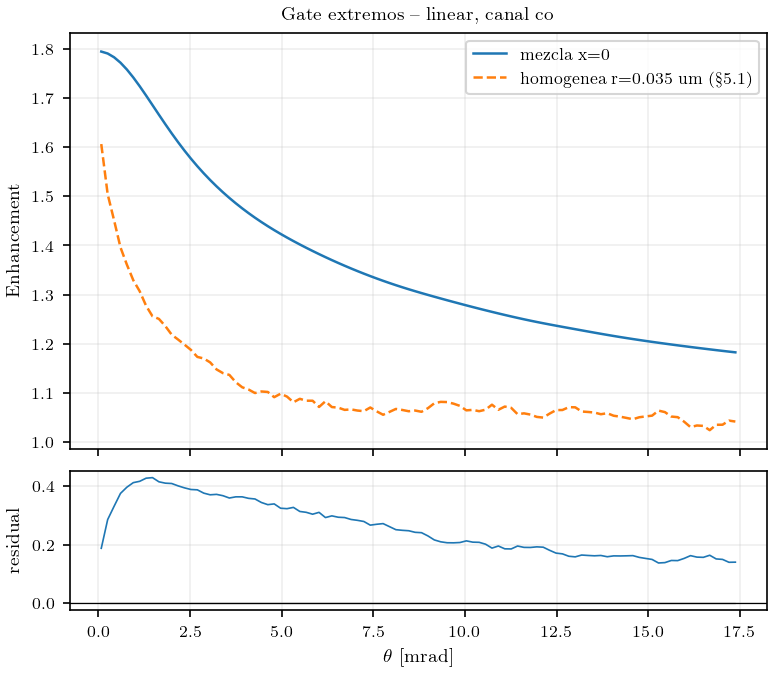

[gate linear x=1 vs r=0.075] chi2/bin = 336147.91 (esperado ~1 si coinciden dentro del ruido)


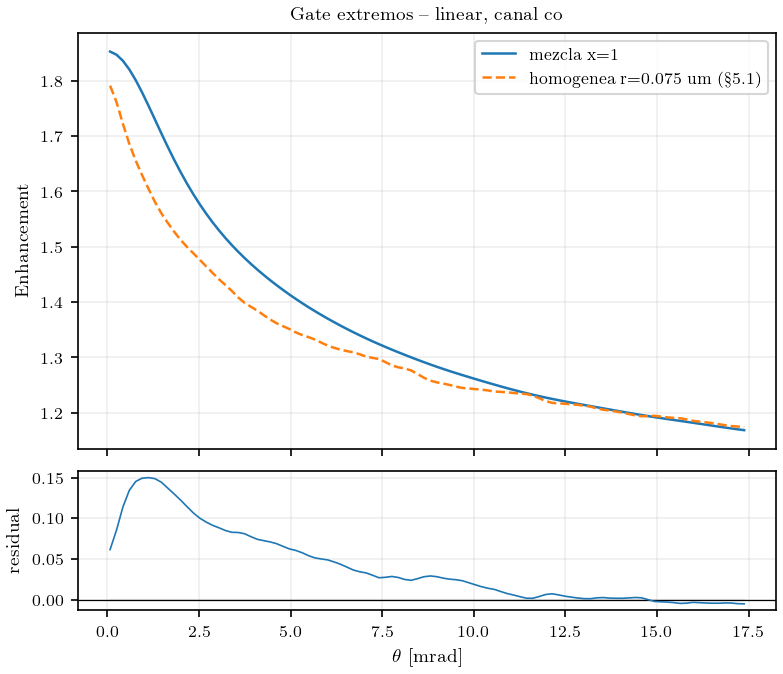

[gate circular x=0 vs r=0.035] chi2/bin = 2225.52 (esperado ~1 si coinciden dentro del ruido)


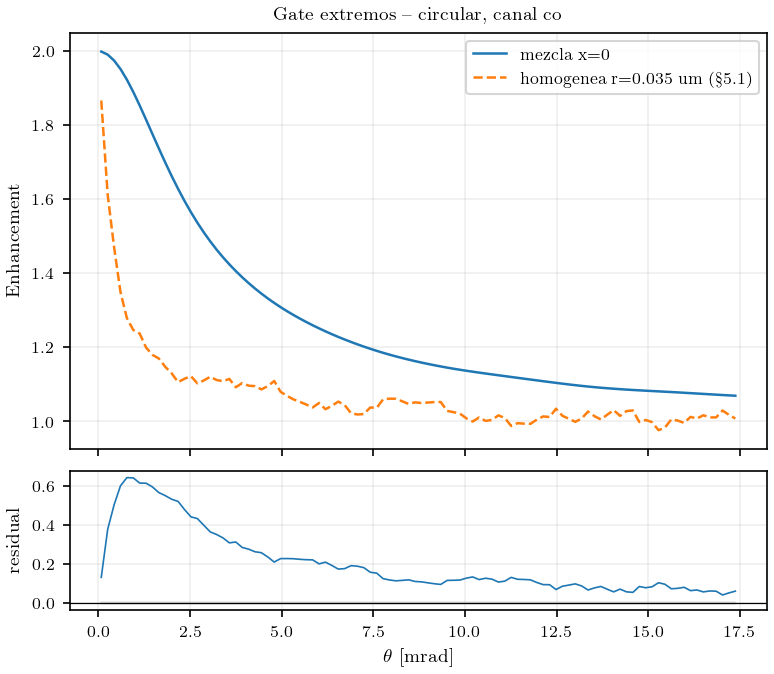

[gate circular x=1 vs r=0.075] chi2/bin = 70758.13 (esperado ~1 si coinciden dentro del ruido)


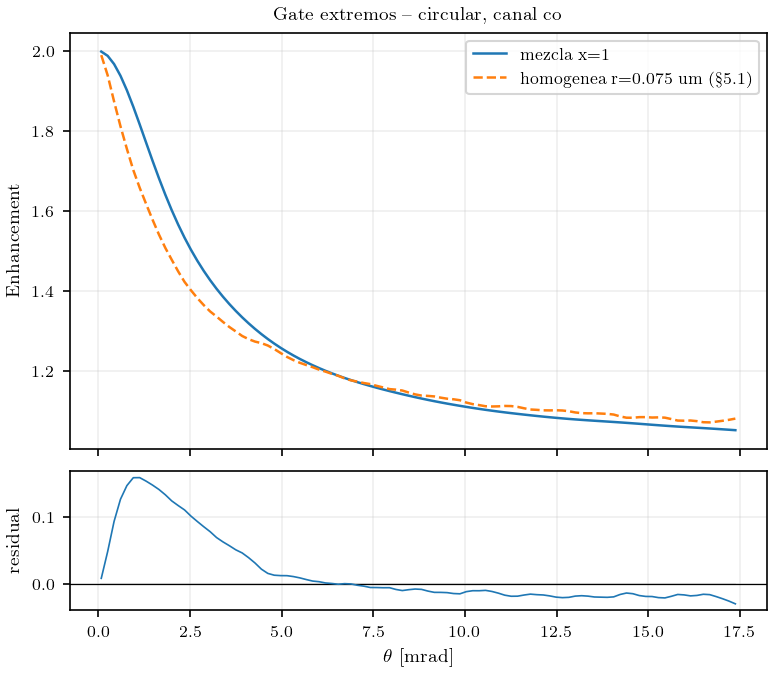

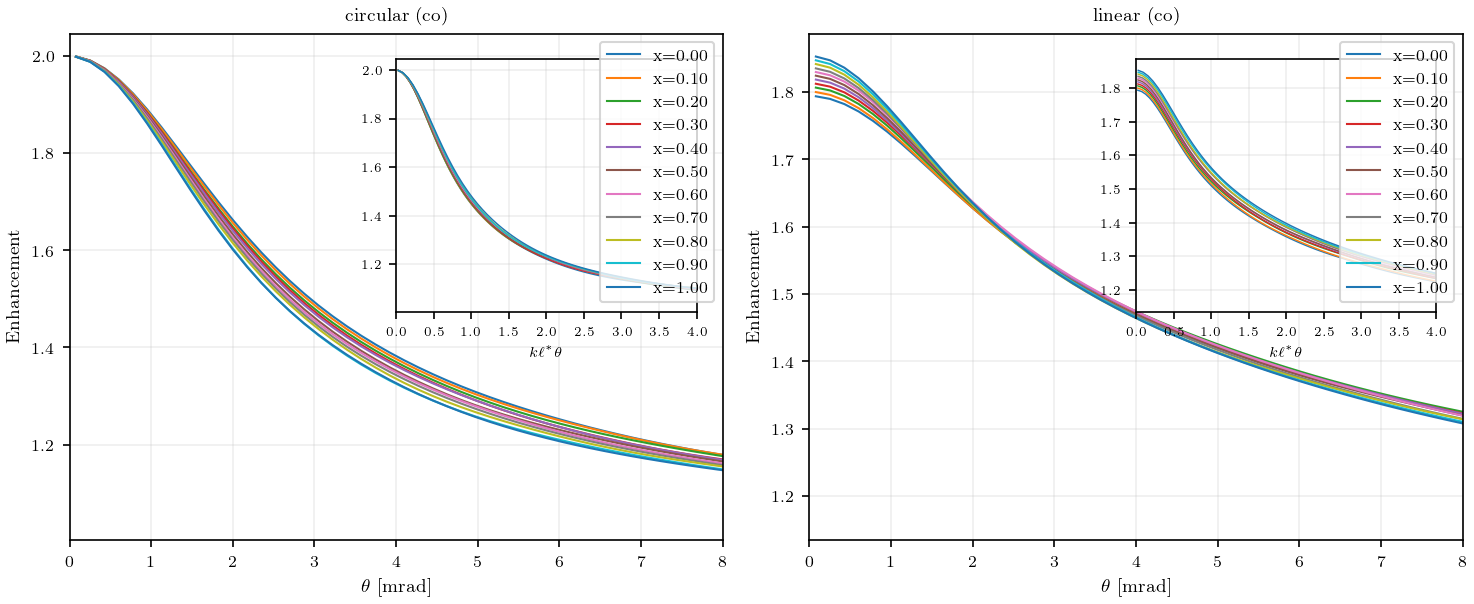

[WARN] theta_FWHM(x) NO monotono en linear: revisa extraccion/ruido


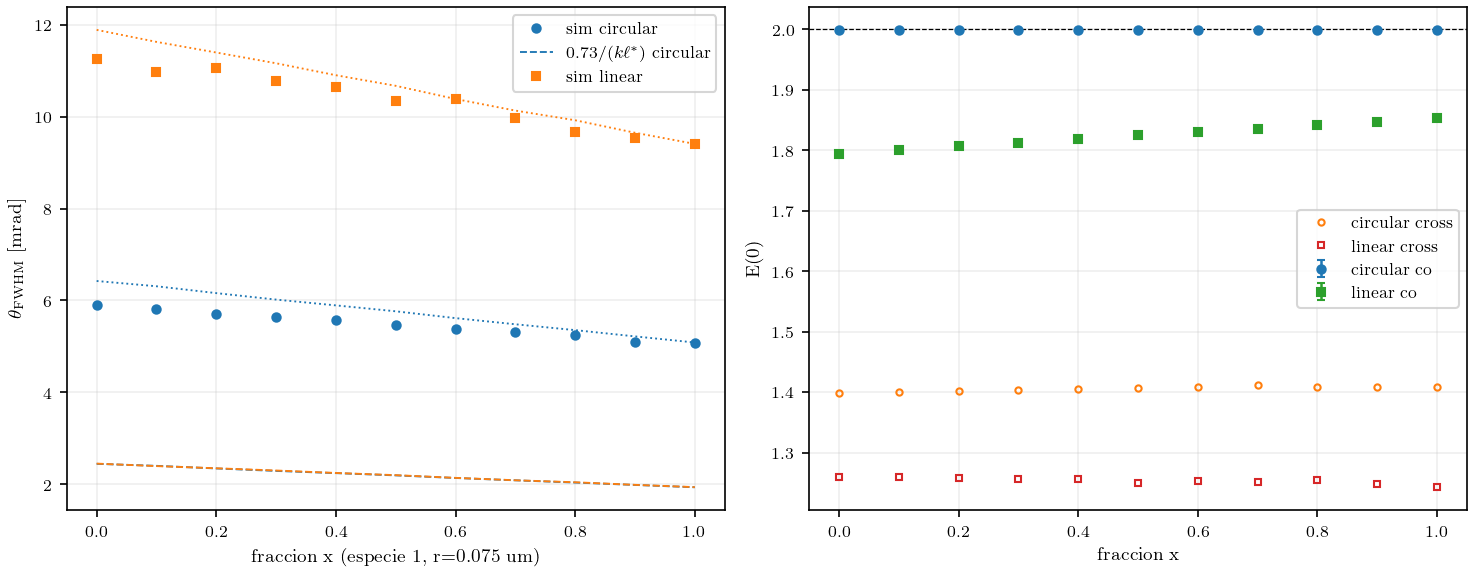

[F12 linear] FWHM sim=10.343 mrad  naive=10.248 mrad (delta=-0.9%)  E0 sim=1.825 naive=1.824  chi2/bin=964698.3


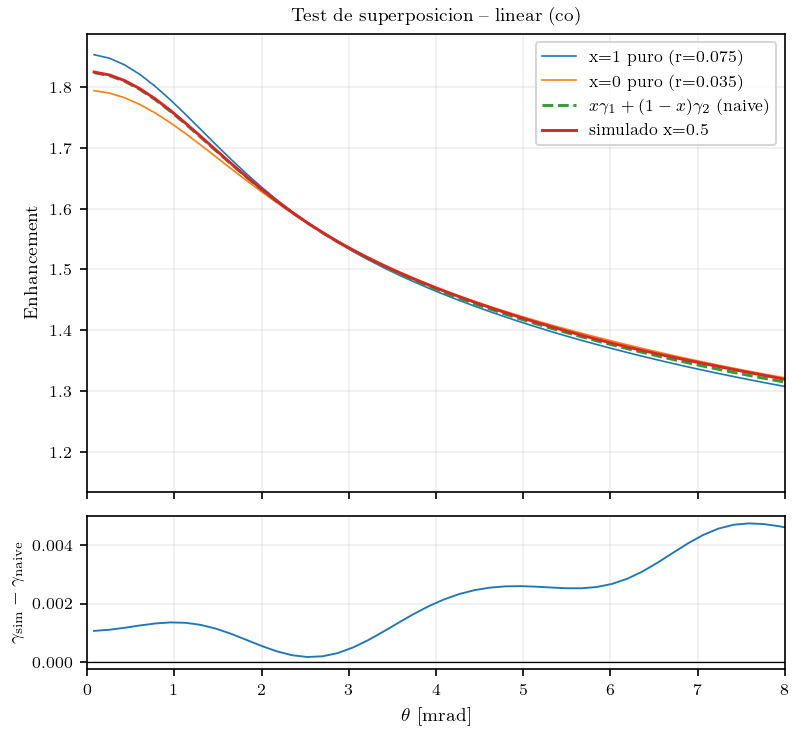

[F12 circular] FWHM sim=5.465 mrad  naive=5.484 mrad (delta=+0.3%)  E0 sim=1.999 naive=1.999  chi2/bin=150165.6


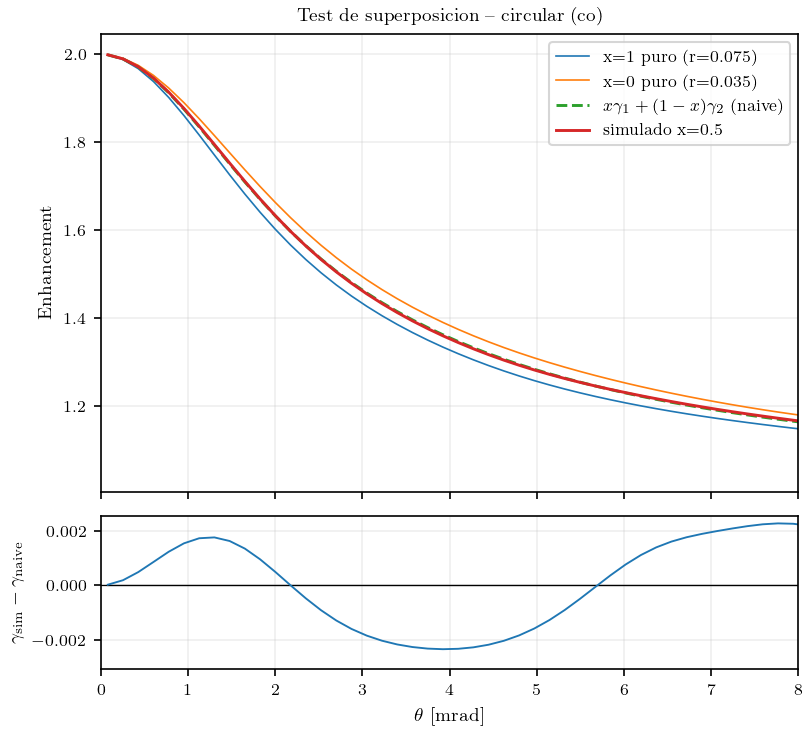


              x       l*_mix[um]  FWHM_circ[mrad]   FWHM_lin[mrad]          E0_circ        E0_lin_co     rho_lin=2-E0
         0.0000          18.3419           5.9084          11.2461           1.9991           1.7941           0.2059
         0.1000          18.6751           5.8226          10.9603           1.9991           1.8003           0.1997
         0.2000          19.1267           5.7141          11.0507           1.9991           1.8070           0.1930
         0.3000          19.5741           5.6404          10.7662           1.9991           1.8127           0.1873
         0.4000          19.9925           5.5818          10.6354           1.9990           1.8189           0.1811
         0.5000          20.4383           5.4653          10.3429           1.9990           1.8247           0.1753
         0.6000          20.9784           5.3878          10.3843           1.9990           1.8302           0.1698
         0.7000          21.4894           5.3216      

In [17]:
# ===========================================================================
# Analisis §5.3 -- Mezclas binarias (Objetivo 1.2)
#
# Produce, a partir de los sweeps YA corridos (PLIN y PCIR):
#   Paso 1  Gate de consistencia: extremos x=0, x=1 vs corridas homogeneas §5.1
#   F10     Familia de perfiles gamma(theta; x) + inset de colapso k*l**theta
#   F11     Observables E(0)(x), theta_FWHM(x) + prediccion de medio efectivo
#   F12     Test de superposicion en x=0.5 (figura clave)
#   Tabla   Degeneracion: (x, FWHM, E0_circ, E0_lin, rho) -> CSV + stdout
#
# No corre ninguna simulacion nueva: todo es postprocesado.
# ===========================================================================
import numpy as np
import matplotlib.pyplot as plt

# from utils.style import apply
# apply(context="paper")

# ===========================================================================
# Configuracion
# ===========================================================================
BASE_DIR = save_path

SWEEPS = {
    "linear":   f"{BASE_DIR}/study_mixture_layer__PLIN",
    "circular": f"{BASE_DIR}/study_mixture_layer__PCIR",   # <-- ajusta el nombre real
}

# Corridas homogeneas de §5.1 para el gate del Paso 1 (ajusta rutas/nombres).
# Clave: (polarizacion, radio_um) -> (ruta_sweep, nombre_run)
HOMOG_RUNS = {
    ("linear",   0.035): (f"{BASE_DIR}/study_rgd_particles__PLIN", "0001_radius_0.04"),
    ("linear",   0.075): (f"{BASE_DIR}/study_rgd_particles__PLIN", "0003_radius_0.07"),
    ("circular", 0.035): (f"{BASE_DIR}/study_rgd_particles__PCIR", "0001_radius_0.04"),
    ("circular", 0.075): (f"{BASE_DIR}/study_rgd_particles__PCIR", "0003_radius_0.07"),
}

FRACTIONS = np.linspace(0.0, 1.0, 11)
RUN_NAME = lambda x: f"fraction_{x:.2f}"

WAVELENGTH = 0.514          # um
N_MEDIUM = 1.33
K_MEDIUM = 2.0 * np.pi * N_MEDIUM / WAVELENGTH   # 1/um
AWM_CONST = 0.73            # theta_FWHM ~ 0.73/(k l*)  (AWM / Muller-Delande)

N_TIP = 8                   # bins promediados para E(0)  (N_THETA=1000 -> tip ruidoso)
REBIN = 10                  # factor de re-binning para FIGURAS (no para extraccion)
F10_FRACTIONS = FRACTIONS
THETA_PLOT_MAX = 8.0        # mrad; el estrechamiento (~20-25%) se pierde a 17.5

# Canales por base. En circular deja None para autodetectar (imprime las claves
# disponibles y elige el de mayor pico como helicity-preserving -- VERIFICA el
# printout la primera vez y fija el nombre aqui).
CHANNELS = {
    "linear":   {"main": "co",  "aux": "cross"},
    "circular": {"main": "co",  "aux": "cross"},
}

# Reduccion por base: circular tiene simetria azimutal exacta -> promedio;
# lineal co se toma en el corte phi=0 (misma convencion que §5.1).
REDUCE = {
    "linear":   phi_cut(0),
    "circular": phi_cut(0),
}
BASIS = {"linear": linear, "circular": circular}

SAVE_FIGS = False           # True -> savefig; False -> plt.show()
OUT_DIR = "."

SHOW = {
    "gate": True,
    "f10": True,
    "f11": True,
    "f12": True,
    "table": True,
}


# ===========================================================================
# Utilidades
# ===========================================================================
def get_profile(run, basis_name):
    """Perfil de realce integrado en tiempo (bin 0 = senal integrada)."""
    prof = cbs_profiles(
        run.processed_cbs("farfield_cbs"),
        basis=BASIS[basis_name], time_index=0, reduce=REDUCE[basis_name],
    )
    return prof


def resolve_channels(prof, basis_name):
    """Fija los nombres de canal; autodetecta en circular si estan en None."""
    ch = CHANNELS[basis_name]
    keys = list(prof.enhancement.keys())
    if ch["main"] is None:
        # helicity-preserving = canal con mayor realce en el tip
        peaks = {k: np.mean(prof.enhancement[k][:N_TIP]) for k in keys}
        main = max(peaks, key=peaks.get)
        aux = [k for k in keys if k != main][0] if len(keys) > 1 else None
        CHANNELS[basis_name] = {"main": main, "aux": aux}
        print(f"[{basis_name}] canales disponibles: {keys}")
        print(f"[{basis_name}] autodeteccion: main='{main}' (E_tip={peaks[main]:.3f})"
              f"  aux='{aux}'  -- VERIFICA y fija en CHANNELS")
    return CHANNELS[basis_name]


def get_params(run):
    """Params planos del run; adapta aqui si el accesor difiere."""
    for attr in ("params_flat", "params"):
        p = getattr(run, attr, None)
        if p is not None:
            return p() if callable(p) else p
    raise AttributeError("No encuentro params en el run: ajusta get_params().")


def rebin(theta, gamma, factor):
    """Re-binning por promedio (solo para figuras)."""
    n = (len(theta) // factor) * factor
    th = theta[:n].reshape(-1, factor).mean(axis=1)
    ga = gamma[:n].reshape(-1, factor).mean(axis=1)
    return th, ga


def estimate_noise(gamma, n_tail=200):
    """Sigma por-bin estimada del scatter de la cola (residual vs media movil)."""
    tail = gamma[-n_tail:]
    kernel = np.ones(15) / 15.0
    smooth = np.convolve(tail, kernel, mode="same")
    return float(np.std(tail[10:-10] - smooth[10:-10]))


def extract_observables(theta, gamma, n_tip=N_TIP, baseline=1.0, rebin_factor=REBIN):
    """E(0) del tip crudo promediado; FWHM del cruce a media altura
    sobre el perfil re-binneado (sin convolucion: el mode='same' de
    np.convolve rellena con ceros y hunde los primeros bins)."""
    theta = np.asarray(theta, float)
    gamma = np.asarray(gamma, float)
    E0 = float(np.mean(gamma[:n_tip]))
    base = float(np.mean(gamma[-100:])) if baseline == "tail" else float(baseline)
    half = base + 0.5 * (E0 - base)

    th_r, ga_r = rebin(theta, gamma, rebin_factor)
    start = max(1, n_tip // rebin_factor)          # no cruzar dentro del tip
    below = np.where(ga_r[start:] < half)[0]
    if len(below) == 0:
        return E0, float("nan")
    i = int(below[0]) + start
    # ga_r[i] < half <= ga_r[i-1]  ->  xp creciente para np.interp
    th_half = float(np.interp(half, [ga_r[i], ga_r[i - 1]], [th_r[i], th_r[i - 1]]))
    return E0, 2.0 * th_half

def savefig_or_show(fig, name):
    if SAVE_FIGS:
        fig.savefig(f"{OUT_DIR}/{name}.pdf", dpi=200, bbox_inches="tight")
        print(f"guardado: {OUT_DIR}/{name}.pdf")
        plt.close(fig)
    else:
        plt.show()

def find_run(sweep_obj, x):
    """Resuelve el nombre real del run por sufijo 'fraction_X.XX'."""
    suffix = f"fraction_{x:.2f}"
    matches = [k for k in sweep_obj.keys() if k.endswith(suffix)]
    if len(matches) != 1:
        raise KeyError(f"'{suffix}': encontrados {matches}")
    return sweep_obj[matches[0]]

# ===========================================================================
# Carga de sweeps
# ===========================================================================
sweeps = {b: load_sweep(path) for b, path in SWEEPS.items()}

profiles, params = {}, {}
for b in sweeps:
    profiles[b], params[b] = {}, {}
    for x in FRACTIONS:
        run = find_run(sweeps[b], x)
        profiles[b][x] = get_profile(run, b)
        params[b][x] = get_params(run)
    resolve_channels(profiles[b][FRACTIONS[0]], b)

# sanity global: E <= 2 en todas las corridas
for b in profiles:
    for x, prof in profiles[b].items():
        for ch, g in prof.enhancement.items():
            gmax = float(np.max(g))
            if gmax > 2.0 + 5 * estimate_noise(np.asarray(g)):
                print(f"[WARN] E>2 en {b}, x={x}, canal {ch}: max={gmax:.3f}")


# ===========================================================================
# Paso 1 -- Gate de consistencia: extremos vs homogeneas §5.1
# ===========================================================================
if SHOW["gate"] and HOMOG_RUNS:
    _homog_cache = {}
    for (b, r), (path, name) in HOMOG_RUNS.items():
        if path not in _homog_cache:
            _homog_cache[path] = load_sweep(path)
        run = _homog_cache[path][name]
        prof_h = get_profile(run, b)
        # extremos: x=1 <-> r=0.075 (especie 1), x=0 <-> r=0.035 (especie 2)
        x_end = 1.0 if np.isclose(r, 0.075) else 0.0
        prof_m = profiles[b][x_end]
        ch = CHANNELS[b]["main"]

        th = np.asarray(prof_m.theta) * 1e3
        gm = np.asarray(prof_m.enhancement[ch])
        gh = np.asarray(prof_h.enhancement[ch])
        sigma = np.sqrt(estimate_noise(gm) ** 2 + estimate_noise(gh) ** 2)

        fig, (ax1, ax2) = plt.subplots(
            2, 1, figsize=(6, 5), sharex=True,
            gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08},
        )
        t1, g1 = rebin(th, gm, REBIN)
        t2, g2 = rebin(th, gh, REBIN)
        ax1.plot(t1, g1, label=f"mezcla x={x_end:.0f}")
        ax1.plot(t2, g2, "--", label=f"homogenea r={r} um (§5.1)")
        ax1.set_ylabel("Enhancement")
        ax1.legend()
        ax1.grid(alpha=0.2)
        ax1.set_title(f"Gate extremos -- {b}, canal {ch}")

        tr, res = rebin(th, gm - gh, REBIN)
        ax2.axhline(0, color="k", lw=0.6)
        ax2.fill_between(tr, -2 * sigma / np.sqrt(REBIN), 2 * sigma / np.sqrt(REBIN),
                         alpha=0.15, color="gray", label=r"$\pm 2\sigma$")
        ax2.plot(tr, res, lw=0.8)
        ax2.set_xlabel(r"$\theta$ [mrad]")
        ax2.set_ylabel("residual")
        ax2.grid(alpha=0.2)

        chi2 = np.mean((gm - gh) ** 2) / sigma ** 2
        print(f"[gate {b} x={x_end:.0f} vs r={r}] chi2/bin = {chi2:.2f} "
              f"(esperado ~1 si coinciden dentro del ruido)")
        savefig_or_show(fig, f"gate_endpoints_{b}_r{r}")
elif SHOW["gate"]:
    print("[gate] HOMOG_RUNS vacio: llena las rutas de §5.1 para correr el gate.")


# ===========================================================================
# F10 -- Familia de perfiles gamma(theta; x) + inset de colapso
# ===========================================================================
if SHOW["f10"]:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
    for ax, b in zip(axes, ["circular", "linear"]):
        ch = CHANNELS[b]["main"]
        for x in F10_FRACTIONS:
            prof = profiles[b][x]
            th, ga = rebin(np.asarray(prof.theta) * 1e3,
                           np.asarray(prof.enhancement[ch]), REBIN)
            ax.plot(th, ga, lw=1.0, label=f"x={x:.2f}")
        ax.set_xlim(0, THETA_PLOT_MAX)
        ax.set_xlabel(r"$\theta$ [mrad]")
        ax.set_ylabel("Enhancement")
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8)
        ax.set_title(f"{b} ({ch})")

        # inset: colapso vs q = k l*(x) theta  -> demostracion visual del
        # medio efectivo (las curvas deben caer una sobre otra)
        axin = ax.inset_axes([0.5, 0.45, 0.46, 0.5])
        for x in F10_FRACTIONS:
            prof = profiles[b][x]
            lstar = params[b][x]["transport_mean_free_path"]
            q = np.asarray(prof.theta) * K_MEDIUM * lstar
            qq, ga = rebin(q, np.asarray(prof.enhancement[ch]), REBIN)
            axin.plot(qq, ga, lw=0.7)
        axin.set_xlim(0, 4)
        axin.set_xlabel(r"$k\ell^*\theta$", fontsize=7)
        axin.tick_params(labelsize=6)
        axin.grid(alpha=0.2)
    fig.tight_layout()
    savefig_or_show(fig, "F10_profile_family")


# ===========================================================================
# F11 -- Observables vs composicion + prediccion de medio efectivo
# ===========================================================================
obs = {}   # obs[base] = dict con arrays E0_main, E0_aux, fwhm_mrad, lstar, sigma_E0
if SHOW["f11"] or SHOW["table"]:
    for b in profiles:
        chm, cha = CHANNELS[b]["main"], CHANNELS[b]["aux"]
        E0m, E0a, fw, ls, sE = [], [], [], [], []
        for x in FRACTIONS:
            prof = profiles[b][x]
            th = np.asarray(prof.theta)
            gm = np.asarray(prof.enhancement[chm])
            e0, fwhm = extract_observables(th, gm)          # baseline=1.0
            E0m.append(e0)
            fw.append(fwhm * 1e3)
            ls.append(params[b][x]["transport_mean_free_path"])
            sE.append(estimate_noise(gm) / np.sqrt(N_TIP))  # error del tip promediado
            if cha is not None:
                e0a, _ = extract_observables(th, np.asarray(prof.enhancement[cha]))
                E0a.append(e0a)
        obs[b] = {
            "E0_main": np.array(E0m), "E0_aux": np.array(E0a) if E0a else None,
            "fwhm_mrad": np.array(fw), "lstar": np.array(ls),
            "sigma_E0": np.array(sE),
        }

if SHOW["f11"]:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    # -- panel 1: theta_FWHM(x) + prediccion medio efectivo --
    for b, marker in [("circular", "o"), ("linear", "s")]:
        o = obs[b]
        ax1.plot(FRACTIONS, o["fwhm_mrad"], marker, ms=4, ls="none",
                 label=f"sim {b}")
        # prediccion AWM absoluta: 0.73/(k l*(x))
        pred = AWM_CONST / (K_MEDIUM * o["lstar"]) * 1e3
        ax1.plot(FRACTIONS, pred, "--", lw=0.9,
                 label=rf"$0.73/(k\ell^*)$ {b}" if b == "circular" else None,
                 color=ax1.lines[-1].get_color())
        # prediccion ANCLADA en x=1: misma forma 1/l*(x), sin constante teorica
        anchored = o["fwhm_mrad"][-1] * o["lstar"][-1] / o["lstar"]
        ax1.plot(FRACTIONS, anchored, ":", lw=0.9,
                 color=ax1.lines[-2].get_color())
    ax1.set_xlabel("fraccion x (especie 1, r=0.075 um)")
    ax1.set_ylabel(r"$\theta_{\mathrm{FWHM}}$ [mrad]")
    ax1.grid(alpha=0.2)
    ax1.legend(fontsize=8)

    # gate de monotonia
    for b in obs:
        d = np.diff(obs[b]["fwhm_mrad"])
        if not (np.all(d <= 0) or np.all(d >= 0)):
            print(f"[WARN] theta_FWHM(x) NO monotono en {b}: revisa extraccion/ruido")

    # -- panel 2: E(0)(x) por canal --
    for b, marker in [("circular", "o"), ("linear", "s")]:
        o = obs[b]
        ax2.errorbar(FRACTIONS, o["E0_main"], yerr=o["sigma_E0"], fmt=marker,
                     ms=4, capsize=2, label=f"{b} {CHANNELS[b]['main']}")
        if o["E0_aux"] is not None:
            ax2.plot(FRACTIONS, o["E0_aux"], marker, ms=3, mfc="none", ls="none",
                     label=f"{b} {CHANNELS[b]['aux']}")
    ax2.axhline(2.0, color="k", lw=0.6, ls="--")
    ax2.set_xlabel("fraccion x")
    ax2.set_ylabel("E(0)")
    ax2.grid(alpha=0.2)
    ax2.legend(fontsize=8)
    fig.tight_layout()
    savefig_or_show(fig, "F11_observables_vs_x")


def naive_profile(prof_x0, prof_x1, x, ch):
    """Superposicion naive a nivel de INTENSIDADES:
    gamma_naive = (x C1 + (1-x) C0 + x I1 + (1-x) I0) / (x I1 + (1-x) I0)."""
    C = x * np.asarray(prof_x1.enhancement[ch]) + (1 - x) * np.asarray(prof_x0.enhancement[ch])
    return C

# ===========================================================================
# F12 -- Test de superposicion en x=0.5 (figura clave)
#   gamma_naive = x*gamma(x=1) + (1-x)*gamma(x=0), con x = share de mu_s.
# ===========================================================================
if SHOW["f12"]:
    X_TEST = 0.5
    for b in profiles:
        ch = CHANNELS[b]["main"]
        th = np.asarray(profiles[b][X_TEST].theta)
        g_sim = np.asarray(profiles[b][X_TEST].enhancement[ch])
        g_1 = np.asarray(profiles[b][1.0].enhancement[ch])
        g_0 = np.asarray(profiles[b][0.0].enhancement[ch])
        g_naive = naive_profile(profiles[b][0.0], profiles[b][1.0], X_TEST, ch)

        sigma = np.sqrt(estimate_noise(g_sim) ** 2
                        + (X_TEST * estimate_noise(g_1)) ** 2
                        + ((1 - X_TEST) * estimate_noise(g_0)) ** 2)

        fig, (ax1, ax2) = plt.subplots(
            2, 1, figsize=(6, 5.5), sharex=True,
            gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08},
        )
        thm = th * 1e3
        for g, style, lab in [(g_1, "-", "x=1 puro (r=0.075)"),
                              (g_0, "-", "x=0 puro (r=0.035)"),
                              (g_naive, "--", r"$x\gamma_1+(1-x)\gamma_2$ (naive)"),
                              (g_sim, "-", "simulado x=0.5")]:
            t, gg = rebin(thm, g, REBIN)
            lw = 1.4 if lab.startswith(("sim", "$")) else 0.8
            ax1.plot(t, gg, style, lw=lw, label=lab)
        ax1.set_xlim(0, THETA_PLOT_MAX)
        ax1.set_ylabel("Enhancement")
        ax1.grid(alpha=0.2)
        ax1.legend(fontsize=8)
        ax1.set_title(f"Test de superposicion -- {b} ({ch})")

        t, res = rebin(thm, g_sim - g_naive, REBIN)
        ax2.axhline(0, color="k", lw=0.6)
        ax2.fill_between(t, -2 * sigma / np.sqrt(REBIN), 2 * sigma / np.sqrt(REBIN),
                         alpha=0.15, color="gray")
        ax2.plot(t, res, lw=0.9)
        ax2.set_xlabel(r"$\theta$ [mrad]")
        ax2.set_ylabel(r"$\gamma_{\rm sim}-\gamma_{\rm naive}$")
        ax2.grid(alpha=0.2)

        # numeros para el texto
        e0_s, fw_s = extract_observables(th, g_sim)
        e0_n, fw_n = extract_observables(th, g_naive)
        chi2 = np.mean((g_sim - g_naive) ** 2) / sigma ** 2
        print(f"[F12 {b}] FWHM sim={fw_s*1e3:.3f} mrad  naive={fw_n*1e3:.3f} mrad "
              f"(delta={100*(fw_n-fw_s)/fw_s:+.1f}%)  "
              f"E0 sim={e0_s:.3f} naive={e0_n:.3f}  chi2/bin={chi2:.1f}")
        savefig_or_show(fig, f"F12_superposition_{b}")


# ===========================================================================
# Tabla de degeneracion -> stdout + CSV
#   theta_FWHM mide solo l*(x) (degenerado con un monodisperso equivalente);
#   rho(x) = 2 - E0 en lineal-co depende de las funciones de fase -> rompe la
#   degeneracion sin necesidad de simulaciones extra.
# ===========================================================================
if SHOW["table"]:
    rows = []
    header = ("x", "l*_mix[um]", "FWHM_circ[mrad]", "FWHM_lin[mrad]",
              "E0_circ", "E0_lin_co", "rho_lin=2-E0")
    print("\n" + "  ".join(f"{h:>15s}" for h in header))
    for i, x in enumerate(FRACTIONS):
        row = (x,
               obs["circular"]["lstar"][i],
               obs["circular"]["fwhm_mrad"][i],
               obs["linear"]["fwhm_mrad"][i],
               obs["circular"]["E0_main"][i],
               obs["linear"]["E0_main"][i],
               2.0 - obs["linear"]["E0_main"][i])
        rows.append(row)
        print("  ".join(f"{v:>15.4f}" for v in row))
    np.savetxt(f"{OUT_DIR}/degeneracy_table.csv", np.array(rows),
               delimiter=",", header=",".join(header), comments="")
    print(f"\nguardado: {OUT_DIR}/degeneracy_table.csv")